In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from tqdm.auto import tqdm
import matplotlib.cm as cm

In [ ]:
carpeta = "weave_L1/"

#OB16170
#archivos_ob = [ "single_3105092.fit", "single_3105094.fit", "single_3105096.fit", "single_3105098.fit", "single_3105100.fit", "single_3105102.fit" ]
#archivo_weave_oficial = "weave_L1/stackcube_3105092.fit"

#OB16169
#archivos_ob = [ "single_3117894.fit", "single_3117896.fit", "single_3117898.fit", "single_3117900.fit", "single_3117902.fit", "single_3117904.fit" ]
#archivo_weave_oficial = "weave_L1/stackcube_3117894.fit"

#OB16168
#archivos_ob = [    "single_3117842.fit", "single_3117844.fit", "single_3117846.fit", "single_3117848.fit", "single_3117850.fit", "single_3117852.fit" ]
#archivo_weave_oficial = "weave_L1/stackcube_3117842.fit"

#OB16167
#archivos_ob = [    "single_3121264.fit", "single_3121266.fit", "single_3121268.fit","single_3121270.fit", "single_3121272.fit", "single_3121274.fit" ]
#archivo_weave_oficial = "weave_L1/stackcube_3121264.fit"

#OB16166
archivos_ob = [    "single_3121049.fit", "single_3121051.fit", "single_3121053.fit","single_3121055.fit", "single_3121057.fit", "single_3121059.fit" ]
archivo_weave_oficial = "weave_L1/stackcube_3121049.fit"

# Datos físicos de las fibras del instrumento WEAVE (LIFU)
fibre_diameter_arcsec = 2.6
factor_drizzle = 0.6
fibre_radius_arcsec = (fibre_diameter_arcsec / 2.0) * factor_drizzle

# Tamaño de los píxeles cuadrados de la imagen final que vamos a crear (spaxels)
pixscale_arcsec = 0.6

# Para calcular cuánta fibra cae en cada spaxel de forma precisa, 
# subdividimos cada spaxel en una cuadrícula más pequeña de 5x5
subsample = 5           


In [ ]:
# =========================================================
# 2. FUNCIONES AUXILIARES
# =========================================================

# Esta función lee la cabecera del FITS y reconstruye el eje longitudes de onda
def build_wave_from_header(header):
    # Busca el valor de incremento por píxel
    cdelt = header.get("CD1_1", header.get("CDELT1"))
    if cdelt is None:
        raise ValueError("No encuentro CD1_1 ni CDELT1")
    # Calcula la longitud de onda para cada píxel: Inicio + Número de píxel * Incremento
    wave = header["CRVAL1"] + (np.arange(header["NAXIS1"]) + 1 - header["CRPIX1"]) * cdelt
    return wave

# Esta función transforma las coordenadas del cielo (grados) a un plano (segundos de arco)
def project_to_arcsec(ra_deg, dec_deg, ra0_deg, dec0_deg):
    x = (ra_deg - ra0_deg) * np.cos(np.deg2rad(dec0_deg)) * 3600.0
    y = (dec_deg - dec0_deg) * 3600.0
    return x, y

# Calcula qué porcentaje de la fibra circular cae dentro de un píxel cuadrado
def circular_overlap_weights(xc, yc, x_edges, y_edges, radius, subsample=5):
    pix = x_edges[1] - x_edges[0] # Tamaño del píxel

    # Para no calcular toda la imagen, nos limitamos solo a los píxeles que están cerca de la fibra
    ix_min = max(0, int(np.floor((xc - radius - x_edges[0]) / pix)))
    ix_max = min(len(x_edges) - 2, int(np.floor((xc + radius - x_edges[0]) / pix)))
    iy_min = max(0, int(np.floor((yc - radius - y_edges[0]) / pix)))
    iy_max = min(len(y_edges) - 2, int(np.floor((yc + radius - y_edges[0]) / pix)))

    results = []

    # Preparamos las posiciones de la mini-cuadrícula de 5x5 dentro de un píxel
    offsets = (np.arange(subsample) + 0.5) / subsample

    # Bucle por los píxeles cercanos
    for iy in range(iy_min, iy_max + 1):
        y0 = y_edges[iy]
        y1 = y_edges[iy + 1]
        ys = y0 + offsets * (y1 - y0) # Coordenadas Y de la mini-cuadrícula

        for ix in range(ix_min, ix_max + 1):
            x0 = x_edges[ix]
            x1 = x_edges[ix + 1]
            xs = x0 + offsets * (x1 - x0) # Coordenadas X de la mini-cuadrícula

            # Creamos la malla de la mini-cuadrícula y comprobamos qué puntos caen dentro del círculo
            XX, YY = np.meshgrid(xs, ys)
            inside = (XX - xc) ** 2 + (YY - yc) ** 2 <= radius ** 2

            # Calculamos la fracción
            frac = np.count_nonzero(inside) / inside.size
            if frac > 0:
                results.append((iy, ix, frac)) # Guardamos qué píxel y qué fracción se lleva

    # Normalizamos los valores para no perder luz ni crear luz extra
    if len(results) > 0:
        total = sum(frac for _, _, frac in results)
        results = [(iy, ix, frac / total) for iy, ix, frac in results]

    return results


In [ ]:
all_ra = []
all_dec = []
all_spec = []
wave_ref = None

for archivo in archivos_ob:
    ruta = os.path.join(carpeta, archivo)

    with fits.open(ruta) as hdul:
        hdr = hdul["BLUE_DATA"].header
        data = np.asarray(hdul["BLUE_DATA"].data, dtype=float) # Espectros crudos
        wave = build_wave_from_header(hdr)

        fibtable = hdul["FIBTABLE"].data
        
        # =========================================================
        # --- RESTA DE CIELO Y FILTRADO DE FIBRAS ---
        # =========================================================
        
        # 1. Identificar qué fibras son de cielo y cuáles de ciencia.
        # La columna se llama 'TARGUSE' y 'S' es Sky y 'T' es Target.
    
        mask_sky = (fibtable['TARGUSE'] == 'S') 
        mask_science = (fibtable['TARGUSE'] == 'T') 

        # 2. Extraer solo los espectros de las fibras que apuntan al cielo
        sky_spectra = data[mask_sky]
        
        # 3. Crear el "Cielo Maestro" (mediana de todas las fibras de cielo para eliminar rayos cósmicos)
        # Usamos nanmedian por si hay píxeles nulos
        master_sky = np.nanmedian(sky_spectra, axis=0)
        
        # 4. Restar el cielo maestro a los espectros de ciencia
        data_clean = data[mask_science] - master_sky
        
        # 5. Quedarnos con las coordenadas de las fibras de ciencia
        ra_clean = np.asarray(fibtable["FIBRERA"][mask_science], dtype=float)
        dec_clean = np.asarray(fibtable["FIBREDEC"][mask_science], dtype=float)


        # Comprobamos que todos los archivos usen la misma escala de longitudes de onda
        if wave_ref is None:
            wave_ref = wave.copy()
        else:
            if len(wave) != len(wave_ref) or not np.allclose(wave, wave_ref, atol=1e-6):
                raise ValueError(f"{archivo}: la rejilla espectral no coincide con las demás")

        # Añadimos a la lista los datos limpios y de ciencia
        all_ra.append(ra_clean)
        all_dec.append(dec_clean)
        all_spec.append(data_clean)

# Juntamos todas las listas. 
all_ra = np.concatenate(all_ra)
all_dec = np.concatenate(all_dec)
all_spec = np.vstack(all_spec) 

nfib_total, nw = all_spec.shape
print(f"Número total de fibras de ciencia a procesar: {nfib_total}")
print(f"Número de longitudes de onda: {nw}")


Número total de fibras de CIENCIA a procesar: 3264
Número de longitudes de onda (planos del cubo): 4701


In [ ]:
# =========================================================
# DEFINIR EL LIENZO DE LA IMAGEN FINAL (La rejilla)
# =========================================================
# Buscamos el centro exacto del cielo de todos nuestros datos
ra0 = np.nanmedian(all_ra)
dec0 = np.nanmedian(all_dec)

# Pasamos todas las coordenadas a segundos de arco respecto al centro
x_arcsec, y_arcsec = project_to_arcsec(all_ra, all_dec, ra0, dec0)

# Calculamos los límites del lienzo, dejando un poco de margen para que no se corten las fibras
margin = fibre_radius_arcsec + pixscale_arcsec
xmin = np.nanmin(x_arcsec) - margin
xmax = np.nanmax(x_arcsec) + margin
ymin = np.nanmin(y_arcsec) - margin
ymax = np.nanmax(y_arcsec) + margin

# Calculamos cuántos píxeles de ancho y alto tendrá la imagen
nx = int(np.ceil((xmax - xmin) / pixscale_arcsec))
ny = int(np.ceil((ymax - ymin) / pixscale_arcsec))

# Definimos los bordes de cada píxel
x_edges = xmin + np.arange(nx + 1) * pixscale_arcsec
y_edges = ymin + np.arange(ny + 1) * pixscale_arcsec

print(f"Tamaño de la imagen final: {nx} píxeles de ancho por {ny} de alto")


# =========================================================
# CONSTRUCCIÓN DEL CUBO POR SOLAPAMIENTO
# =========================================================
# Creamos el cubo 3D vacío (longitud de onda, alto, ancho)
cube_flux = np.zeros((nw, ny, nx), dtype=np.float32)

# Creamos una imagen 2D vacía para contar cuántas fibras caen en cada píxel (los pesos)
cube_weight = np.zeros((ny, nx), dtype=np.float32)

for i in tqdm(range(nfib_total), desc="Proyectando fibras en el cubo"):

    xc = x_arcsec[i]
    yc = y_arcsec[i]
    spec = all_spec[i]  # Extraemos el espectro entero de esa fibra

    # Usamos nuestra función para saber qué porcentaje de esta fibra cae en qué píxeles
    overlaps = circular_overlap_weights(
        xc, yc,
        x_edges, y_edges,
        radius=fibre_radius_arcsec,
        subsample=subsample
    )

    if len(overlaps) == 0:
        continue

    # Vamos inyectando el espectro multiplicado por su porcentaje correspondiente
    for iy, ix, w in overlaps:
        cube_flux[:, iy, ix] += spec * w
        cube_weight[iy, ix] += w

# Normalización: como hay zonas donde caen muchas fibras (el dither se solapa),
# dividimos la luz acumulada entre el peso total para sacar un promedio y que no brille de más.
cube = np.full_like(cube_flux, np.nan)
good = cube_weight > 0

cube[:, good] = (cube_flux[:, good] / cube_weight[good]) 

print("Cubo 3D construido")


Tamaño de la imagen final: 140 píxeles de ancho por 158 de alto


Proyectando fibras en el cubo: 100%|██████████| 3264/3264 [00:03<00:00, 1026.33it/s]


¡Cubo 3D construido con éxito!


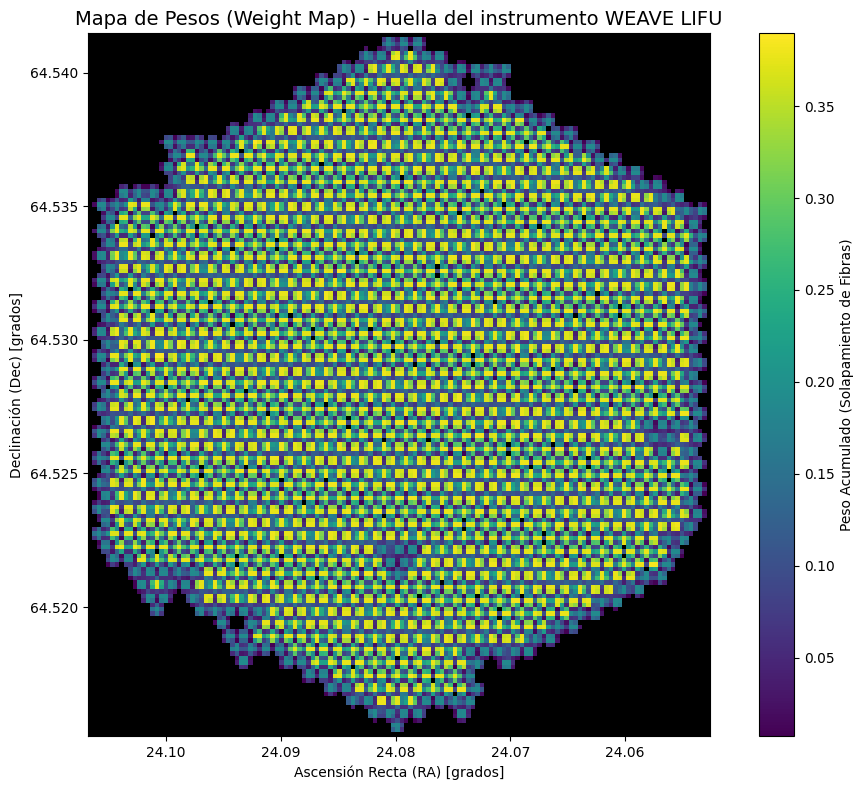

In [ ]:

# =============================================================================
# VISUALIZACIÓN DEL MAPA DE PESOS (CUBE WEIGHT)
# =============================================================================

ra_min = ra0 + (xmin / 3600.0) / np.cos(np.deg2rad(dec0))
ra_max = ra0 + (xmax / 3600.0) / np.cos(np.deg2rad(dec0))
dec_min = dec0 + (ymin / 3600.0)
dec_max = dec0 + (ymax / 3600.0)
aspect_ratio = 1.0 / np.cos(np.deg2rad(dec0))

weight_map = cube_weight.copy()

# Cambiamos los 0 (zonas fuera del hexágono donde no cayó ninguna fibra) por NaN
# Así le decimos a matplotlib que pinte ese fondo de negro
weight_map[weight_map == 0] = np.nan

cmap_w = cm.viridis.copy()
cmap_w.set_bad(color='black')

plt.figure(figsize=(10, 8))

im = plt.imshow(weight_map, origin='lower', 
                extent=[ra_min, ra_max, dec_min, dec_max], 
                aspect=aspect_ratio, cmap=cmap_w)

plt.colorbar(im, label="Peso Acumulado (Solapamiento de Fibras)")
plt.xlabel("Ascensión Recta (RA) [grados]")
plt.ylabel("Declinación (Dec) [grados]")
plt.title("Mapa de Pesos - Huella del instrumento WEAVE LIFU", fontsize=14)

if plt.xlim()[0] < plt.xlim()[1]:
    plt.gca().invert_xaxis()

plt.tight_layout()
plt.show()

In [ ]:

# =========================================================
# GUARDAR EL CUBO DEFINITIVO 
# =========================================================

# 1. Calculamos los parámetros del eje Z (espectral)
lambda_start = wave_ref[0]
lambda_step = wave_ref[1] - wave_ref[0]

# 2. Creamos la extensión principal para los DATOS DE FLUJO
hdu_flux = fits.PrimaryHDU(cube)
hdr = hdu_flux.header
hdr['EXTNAME'] = 'FLUX'

hdr['CTYPE1'] = 'RA---TAN'  
hdr['CTYPE2'] = 'DEC--TAN'  
hdr['CTYPE3'] = 'WAVE'      
hdr['CUNIT3'] = 'Angstrom'  

ref_pixel_x = -xmin / pixscale_arcsec + 1
ref_pixel_y = -ymin / pixscale_arcsec + 1

hdr['CRPIX1'] = ref_pixel_x   
hdr['CRPIX2'] = ref_pixel_y   
hdr['CRPIX3'] = 1             

hdr['CRVAL1'] = ra0           
hdr['CRVAL2'] = dec0          
hdr['CRVAL3'] = lambda_start             

hdr['CDELT1'] = -pixscale_arcsec / 3600.0  
hdr['CDELT2'] = pixscale_arcsec / 3600.0   
hdr['CDELT3'] = lambda_step     

hdr['NEXP'] = (6, 'Numero de exposiciones apiladas') 

hdu_weight = fits.ImageHDU(cube_weight)
hdu_weight.header['EXTNAME'] = 'WEIGHT'

hdul = fits.HDUList([hdu_flux, hdu_weight])

carpeta_salida = "mis_cubos"
os.makedirs(carpeta_salida, exist_ok=True)
output_filename = os.path.join(carpeta_salida, "mi_cubo_OB16166.fits")

hdul.writeto(output_filename, overwrite=True)

print(f"Cubo guardado en: '{output_filename}'")


Cubo guardado exitosamente en: 'mis_cubos/mi_cubo_OB16166.fits'
